In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

print("Python is working!")
print("Pandas version:",pd.__version__)

Python is working!
Pandas version: 3.0.3


In [15]:
import pdfplumber
import pandas as pd
import os

# Read from local file
pdf_path = "../data/csn-annual-data-book-2024.pdf"

# First check the file exists
if not os.path.exists(pdf_path):
    print("FILE NOT FOUND. Check the path.")
    print("Current folder:", os.getcwd())
    print("Files in data folder:", os.listdir("../data"))
else:
    print("File found! Opening...")
    all_tables = []
    with pdfplumber.open(pdf_path) as pdf:
        print(f"Total pages in PDF: {len(pdf.pages)}")
        for i, page in enumerate(pdf.pages):
            tables = page.extract_tables()
            for j, table in enumerate(tables):
                if table and len(table) > 1:
                    df = pd.DataFrame(table[1:], columns=table[0])
                    df['source_page'] = i + 1
                    df['table_num'] = j
                    all_tables.append(df)
    print(f"Done! Total tables extracted: {len(all_tables)}")
    for idx, df in enumerate(all_tables):
        cols = [c for c in df.columns if c not in ['source_page', 'table_num']]
        print(f"Table {idx} | Page {df['source_page'].iloc[0]} | {df.shape[0]} rows | Columns: {cols}")

File found! Opening...
Total pages in PDF: 92
Done! Total tables extracted: 211
Table 0 | Page 6 | 3 rows | Columns: ['CONSUMER\nSENTINEL\nNETWORK\nDATA BOOK 2024\nSNAPSHOT', '6.5\nMILLION\nREPORTS', nan, 'TOP THREE CATEGORIES\n1Credit Bureaus and Information Furnishers\n2Identity Theft\n3Imposter Scams']
Table 1 | Page 7 | 7 rows | Columns: ['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '6.1', '4M', '', '6.47M']
Table 2 | Page 7 | 12 rows | Columns: ['Year', '# of Reports']
Table 3 | Page 7 | 12 rows | Columns: ['Year', '# of Reports']
Table 4 | Page 8 | 31 rows | Columns: ['Report Categories', nan, nan, nan]
Table 5 | Page 9 | 2 rows | Columns: ['Report Type', nan]
Table 6 | Page 9 | 1 rows | Columns: ['']
Table 7 | Page 9 | 12 rows | Columns: ['Top 10 Fraud Categories', nan, nan, nan, nan, nan]
Table 8 | Page 9 | 8 rows | Columns: ['Identity Theft Types', nan, nan]
Table 9 | Page 9 | 12 rows | Columns: ['Top 10 Other Categories', nan, nan]
Table 10 | Pa

In [17]:
# First just print the raw data from each key table
# so we can see exactly what's inside before cleaning

print("=== TABLE 2 (Yearly Reports) ===")
print(all_tables[2])

print("\n=== TABLE 7 (Top 10 Fraud Categories) ===")
print(all_tables[7])

print("\n=== TABLE 17 (Contact Methods) ===")
print(all_tables[17])

print("\n=== TABLE 18 (Fraud by Age) ===")
print(all_tables[18])

print("\n=== TABLE 38 (State Rankings) ===")
print(all_tables[38])

print("\n=== TABLE 210 (State Fraud Losses) ===")
print(all_tables[210])

=== TABLE 2 (Yearly Reports) ===
    Year # of Reports  source_page  table_num
0   2001      325,519            7          1
1   2002      551,622            7          1
2   2003      713,657            7          1
3   2004      860,383            7          1
4   2005      909,314            7          1
5   2006      906,129            7          1
6   2007    1,070,447            7          1
7   2008    1,261,124            7          1
8   2009    1,428,977            7          1
9   2010    1,470,306            7          1
10  2011    1,898,543            7          1
11  2012    2,115,079            7          1

=== TABLE 7 (Top 10 Fraud Categories) ===
                    Top 10 Fraud Categories  \
0                             Rank Category   
1                          1 Imposter Scams   
2                                         2   
3                                       NaN   
4          3 Business and Job Opportunities   
5                                         4 

In [20]:
import re
import os

# ── TABLE 2: Yearly reports ──────────────────────────────────────────
df_yearly = all_tables[2][['Year', '# of Reports']].copy()
df_yearly.columns = ['year', 'reports']
df_yearly['year'] = pd.to_numeric(df_yearly['year'], errors='coerce')
df_yearly['reports'] = df_yearly['reports'].astype(str).str.replace(',', '').str.strip()
df_yearly['reports'] = pd.to_numeric(df_yearly['reports'], errors='coerce')
df_yearly = df_yearly.dropna()
print("=== YEARLY REPORTS ===")
print(df_yearly)

# ── TABLE 7: Top 10 Fraud Categories ────────────────────────────────
fraud_data = {
    'category': [
        'Imposter Scams',
        'Online Shopping and Negative Reviews',
        'Business and Job Opportunities',
        'Investment Related',
        'Internet Services',
        'Prizes Sweepstakes and Lotteries',
        'Telephone and Mobile Services',
        'Health Care',
        'Travel Vacations and Timeshare Plans',
        'Mortgage Foreclosure Relief and Debt Management'
    ],
    'reports': [845806, 383441, 126217, 118960, 118261, 97350, 92520, 78763, 58347, 34159],
    'pct_loss': [22, 76, 36, 79, 28, 22, 39, 51, 67, 21],
    'total_loss_M': [2952, 432, 751, 5697, 164, 351, 56, 80, 274, 82],
    'median_loss': [800, 130, 2250, 9196, 300, 1000, 240, 283, 922, 1500]
}
df_fraud = pd.DataFrame(fraud_data)
print("\n=== FRAUD CATEGORIES ===")
print(df_fraud)

# ── TABLE 17: Contact Methods ────────────────────────────────────────
contact_data = {
    'contact_method': [
        'Email', 'Phone call', 'Text', 'Social Media',
        'Website or Apps', 'Other', 'Mail', 'Online Ad or Pop-up'
    ],
    'reports': [371651, 284659, 246784, 186826, 186663, 148288, 42108, 42023],
    'total_loss_M': [502, 948, 470, 1858, 976, 1072, 90, 246],
    'median_loss': [600, 1500, 1000, 409, 200, 633, 990, 180]
}
df_contact = pd.DataFrame(contact_data)
print("\n=== CONTACT METHODS ===")
print(df_contact)

# ── TABLE 210: State Fraud Losses ────────────────────────────────────
df_raw_states = all_tables[210].copy()
df_raw_states.columns = ['state', 'combined', 'c2', 'c3', 'c4', 'source_page', 'table_num']
df_raw_states = df_raw_states[df_raw_states['state'] != 'State'].copy()
df_raw_states = df_raw_states[df_raw_states['combined'].notna()].copy()

def parse_state_row(text):
    text = str(text)
    reports = re.search(r'^([\d,]+)', text)
    loss = re.search(r'\$([\d,]+)', text)
    median = re.search(r'\$[\d,]+\s+\$([\d,]+)', text)
    return {
        'reports': int(reports.group(1).replace(',', '')) if reports else None,
        'total_loss': int(loss.group(1).replace(',', '')) if loss else None,
        'median_loss': int(median.group(1).replace(',', '')) if median else None
    }

parsed = df_raw_states['combined'].apply(parse_state_row)
df_states = pd.DataFrame(list(parsed))
df_states.insert(0, 'state', df_raw_states['state'].values)
df_states = df_states.dropna()
print("\n=== STATE LOSSES (first 10) ===")
print(df_states.head(10))

# ── Save all clean tables ────────────────────────────────────────────
os.makedirs('../output', exist_ok=True)
df_yearly.to_csv('../output/yearly_reports.csv', index=False)
df_fraud.to_csv('../output/fraud_categories.csv', index=False)
df_contact.to_csv('../output/contact_methods.csv', index=False)
df_states.to_csv('../output/state_losses.csv', index=False)

print("\nAll 4 clean tables saved to output/ folder!")
print(f"  yearly_reports.csv   — {len(df_yearly)} rows")
print(f"  fraud_categories.csv — {len(df_fraud)} rows")
print(f"  contact_methods.csv  — {len(df_contact)} rows")
print(f"  state_losses.csv     — {len(df_states)} rows")

=== YEARLY REPORTS ===
    year  reports
0   2001   325519
1   2002   551622
2   2003   713657
3   2004   860383
4   2005   909314
5   2006   906129
6   2007  1070447
7   2008  1261124
8   2009  1428977
9   2010  1470306
10  2011  1898543
11  2012  2115079

=== FRAUD CATEGORIES ===
                                          category  reports  pct_loss  \
0                                   Imposter Scams   845806        22   
1             Online Shopping and Negative Reviews   383441        76   
2                   Business and Job Opportunities   126217        36   
3                               Investment Related   118960        79   
4                                Internet Services   118261        28   
5                 Prizes Sweepstakes and Lotteries    97350        22   
6                    Telephone and Mobile Services    92520        39   
7                                      Health Care    78763        51   
8             Travel Vacations and Timeshare Plans    58347 

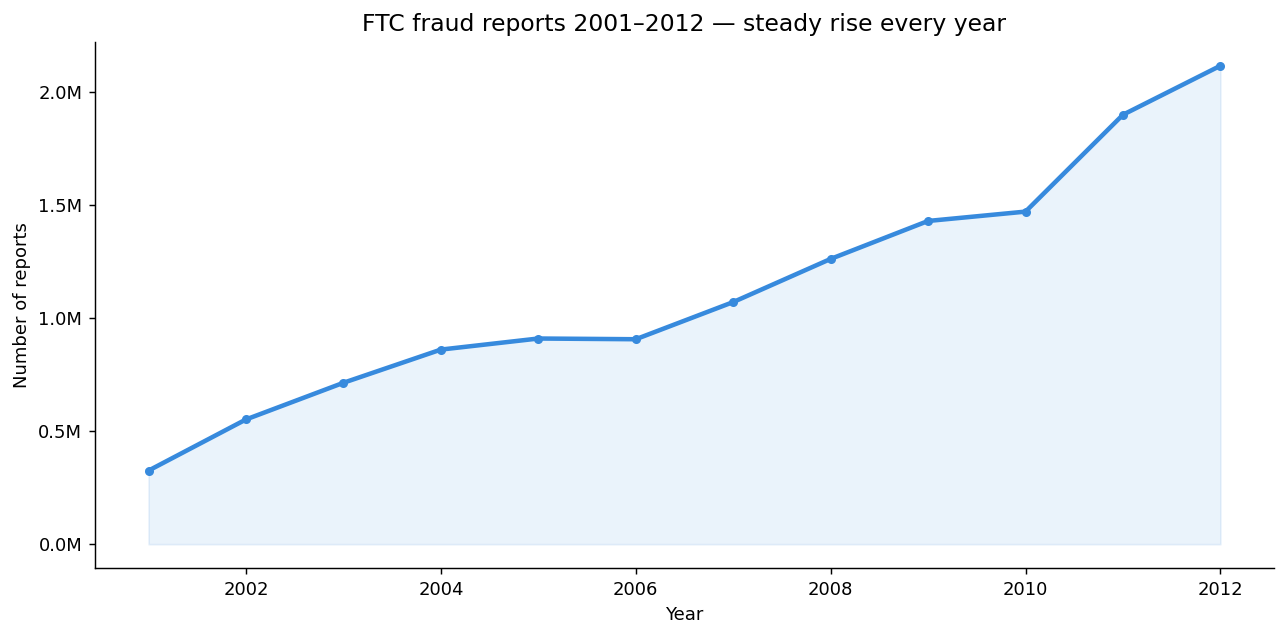

Saved chart1_yearly_trend.png


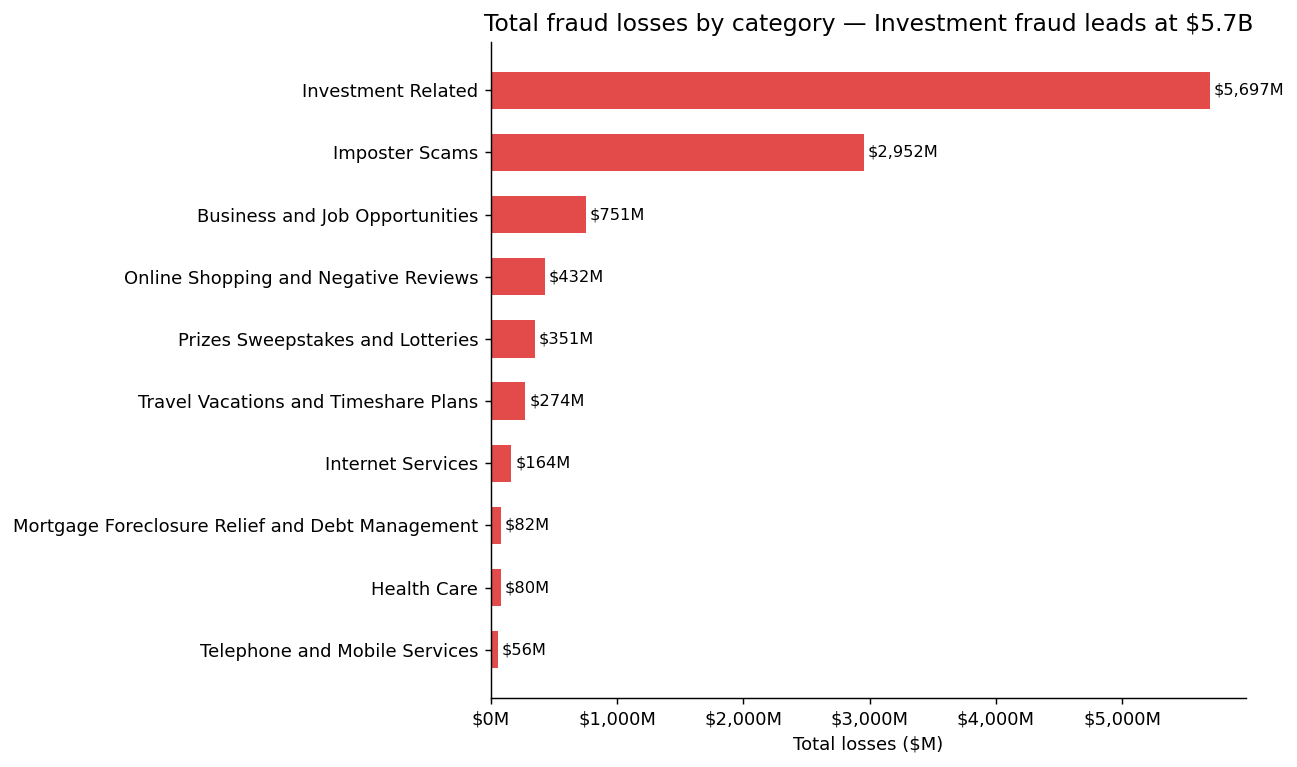

Saved chart2_fraud_categories.png


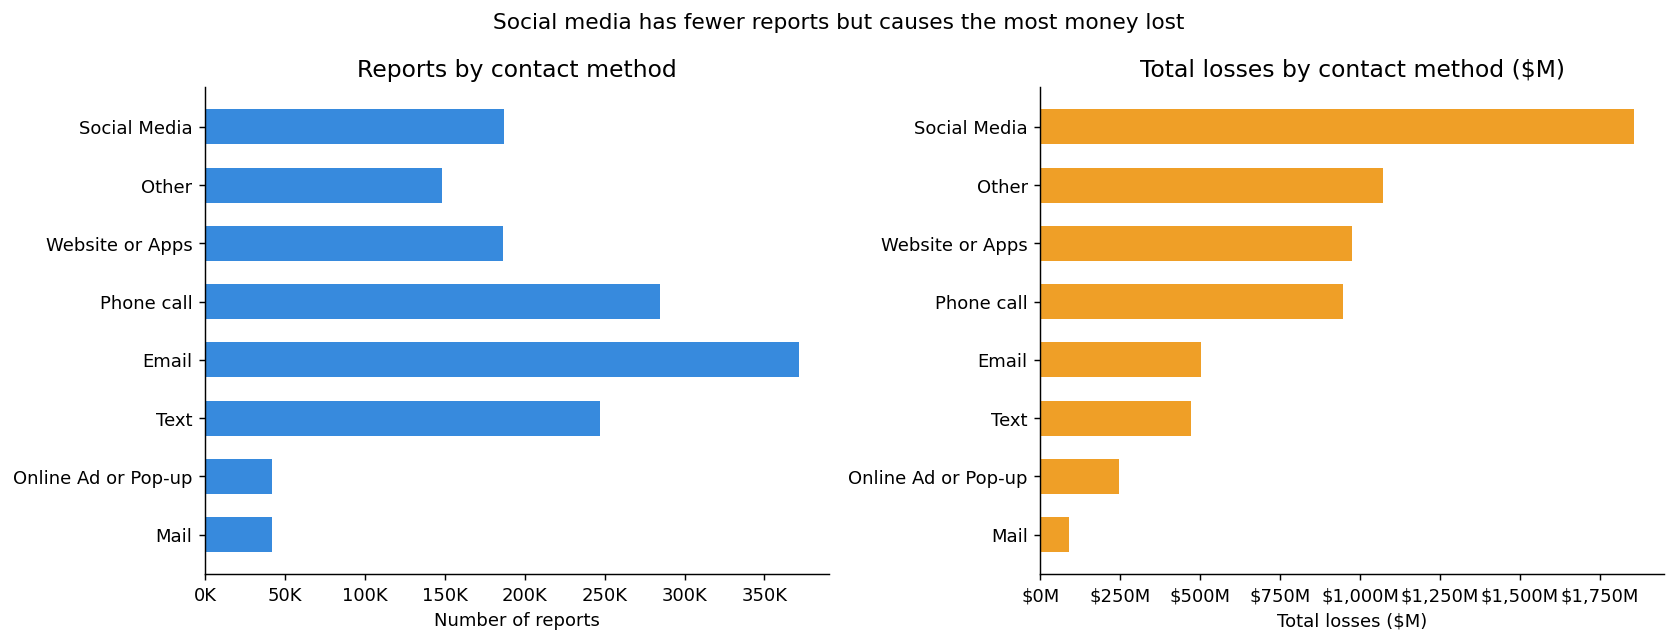

Saved chart3_contact_methods.png


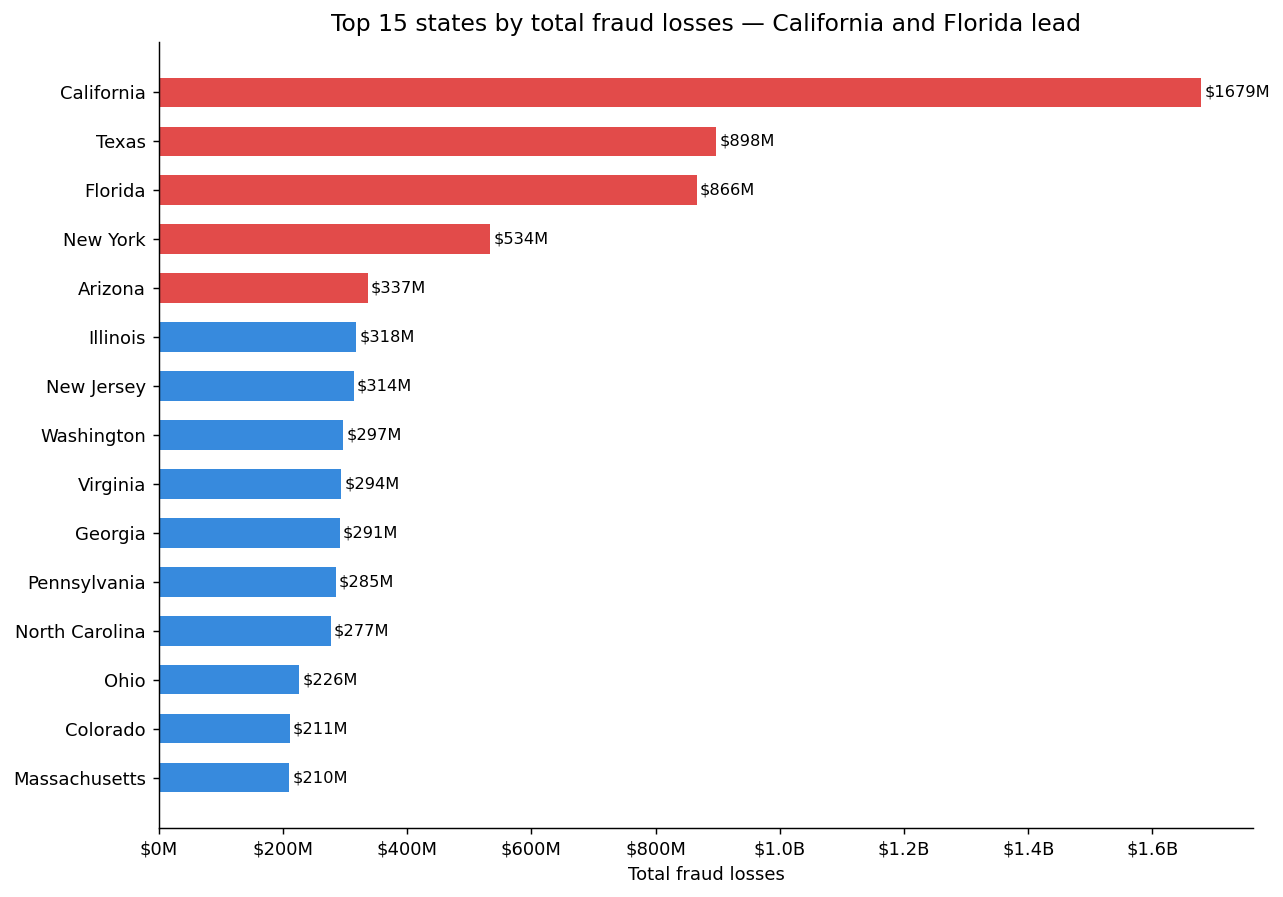

Saved chart4_state_losses.png


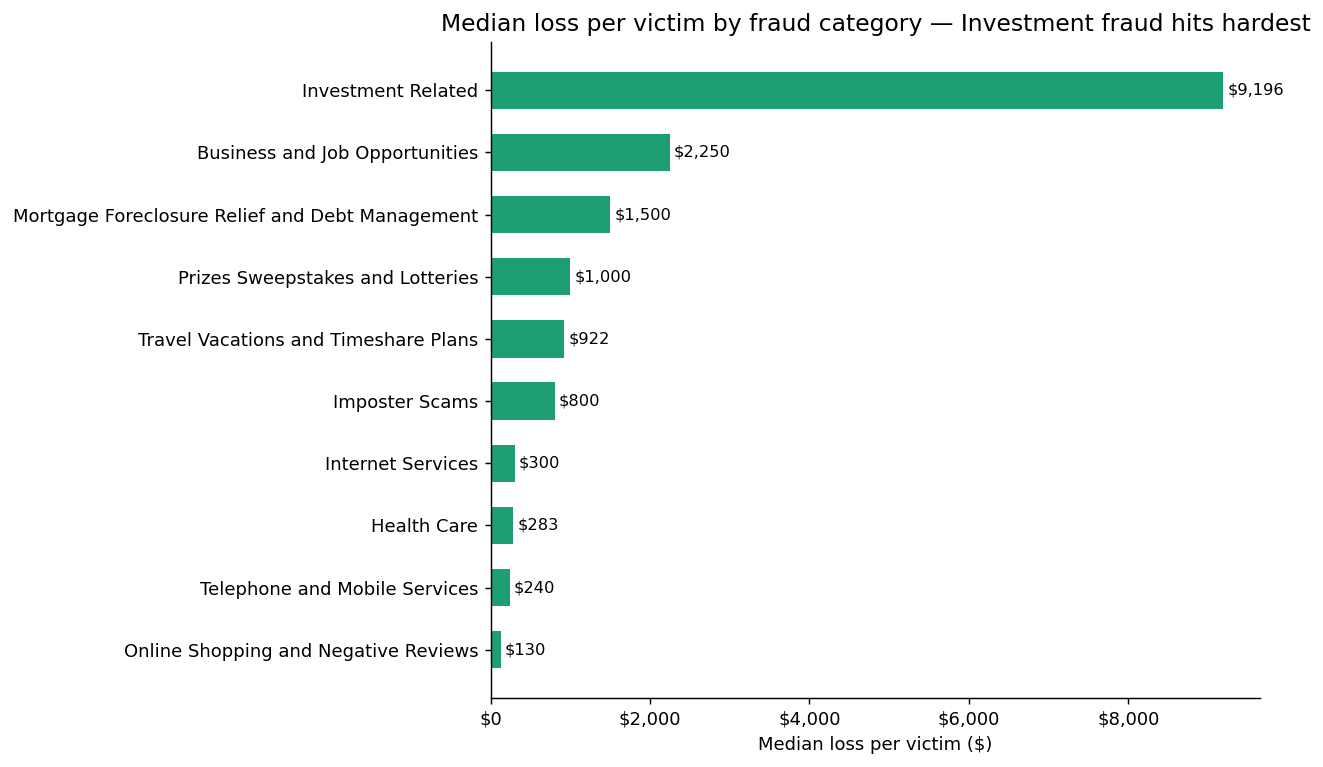

Saved chart5_median_loss.png

All 5 charts saved to output/ folder!


In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

os.makedirs('../output', exist_ok=True)

BLUE   = '#378ADD'
RED    = '#E24B4A'
AMBER  = '#EF9F27'
TEAL   = '#1D9E75'

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': '500',
    'font.family': 'sans-serif'
})

# ── CHART 1: Yearly fraud reports trend ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_yearly['year'], df_yearly['reports'], color=BLUE, linewidth=2.5, marker='o', markersize=4)
ax.fill_between(df_yearly['year'], df_yearly['reports'], alpha=0.1, color=BLUE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_title('FTC fraud reports 2001–2012 — steady rise every year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of reports')
plt.tight_layout()
plt.savefig('../output/chart1_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved chart1_yearly_trend.png')

# ── CHART 2: Top fraud categories by total loss ──────────────────────
df_fraud_sorted = df_fraud.sort_values('total_loss_M', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_fraud_sorted['category'], df_fraud_sorted['total_loss_M'], color=RED, height=0.6)
for bar, val in zip(bars, df_fraud_sorted['total_loss_M']):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'${val:,}M', va='center', fontsize=9)
ax.set_title('Total fraud losses by category — Investment fraud leads at $5.7B')
ax.set_xlabel('Total losses ($M)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
plt.tight_layout()
plt.savefig('../output/chart2_fraud_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved chart2_fraud_categories.png')

# ── CHART 3: Contact methods — reports vs losses ─────────────────────
df_contact_sorted = df_contact.sort_values('total_loss_M', ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(df_contact_sorted['contact_method'], df_contact_sorted['reports'], color=BLUE, height=0.6)
axes[0].set_title('Reports by contact method')
axes[0].set_xlabel('Number of reports')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

axes[1].barh(df_contact_sorted['contact_method'], df_contact_sorted['total_loss_M'], color=AMBER, height=0.6)
axes[1].set_title('Total losses by contact method ($M)')
axes[1].set_xlabel('Total losses ($M)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))

plt.suptitle('Social media has fewer reports but causes the most money lost', fontsize=12)
plt.tight_layout()
plt.savefig('../output/chart3_contact_methods.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved chart3_contact_methods.png')

# ── CHART 4: Top 15 states by total fraud loss ───────────────────────
df_top_states = df_states.sort_values('total_loss', ascending=False).head(15)
df_top_states_plot = df_top_states.sort_values('total_loss', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [RED if i >= 10 else BLUE for i in range(len(df_top_states_plot))]
bars = ax.barh(df_top_states_plot['state'], df_top_states_plot['total_loss'], color=colors, height=0.6)
for bar, val in zip(bars, df_top_states_plot['total_loss']):
    ax.text(bar.get_width() + 5e6, bar.get_y() + bar.get_height()/2,
            f'${val/1e6:.0f}M', va='center', fontsize=9)
ax.set_title('Top 15 states by total fraud losses — California and Florida lead')
ax.set_xlabel('Total fraud losses')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B' if x >= 1e9 else f'${x/1e6:.0f}M'))
plt.tight_layout()
plt.savefig('../output/chart4_state_losses.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved chart4_state_losses.png')

# ── CHART 5: Median loss by fraud category ───────────────────────────
df_fraud_median = df_fraud.sort_values('median_loss', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_fraud_median['category'], df_fraud_median['median_loss'], color=TEAL, height=0.6)
for bar, val in zip(bars, df_fraud_median['median_loss']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'${val:,}', va='center', fontsize=9)
ax.set_title('Median loss per victim by fraud category — Investment fraud hits hardest')
ax.set_xlabel('Median loss per victim ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('../output/chart5_median_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved chart5_median_loss.png')

print('\nAll 5 charts saved to output/ folder!')

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb
import shap
import numpy as np

# ── Build ML dataset from state losses table ─────────────────────────
# Goal: predict which states have HIGH fraud loss per person
# Feature: reports, median_loss
# Target: is total_loss above the national median? (1 = high loss state)

df_ml = df_states.copy()

# Create target variable — high loss state = above median total loss
median_loss_threshold = df_ml['total_loss'].median()
df_ml['high_loss'] = (df_ml['total_loss'] > median_loss_threshold).astype(int)

# Feature: loss per report (efficiency of fraud in that state)
df_ml['loss_per_report'] = df_ml['total_loss'] / df_ml['reports']

# Encode state name as a number
le = LabelEncoder()
df_ml['state_encoded'] = le.fit_transform(df_ml['state'])

print("Dataset preview:")
print(df_ml[['state', 'reports', 'total_loss', 'median_loss', 'loss_per_report', 'high_loss']].head(10))
print(f"\nTotal states: {len(df_ml)}")
print(f"High loss states: {df_ml['high_loss'].sum()}")
print(f"Low loss states: {(df_ml['high_loss']==0).sum()}")
print(f"\nMedian total loss threshold: ${median_loss_threshold:,.0f}")

Dataset preview:
                  state  reports  total_loss  median_loss  loss_per_report  \
0               Alabama    26049   104201969          400      4000.229145   
1                Alaska     4917    26942595          525      5479.478340   
2               Arizona    54367   336716502          600      6193.398606   
3              Arkansas    14393    52115298          375      3620.878066   
4            California   238705  1678703608          542      7032.544806   
5              Colorado    44945   210727907          500      4688.572856   
6           Connecticut    20825    90349831          432      4338.527299   
7              Delaware     7540    34282919          466      4546.806233   
8  District of Columbia     7082    30392313          448      4291.487292   
9               Florida   159307   866069909          520      5436.483701   

   high_loss  
0          0  
1          0  
2          1  
3          0  
4          1  
5          1  
6          0  
7   

c:\Personal_project_Resume\ftc_fraud_2024\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== MODEL RESULTS ===
              precision    recall  f1-score   support

    Low Loss       1.00      1.00      1.00         6
   High Loss       1.00      1.00      1.00         5

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11

AUC-ROC Score: 1.000


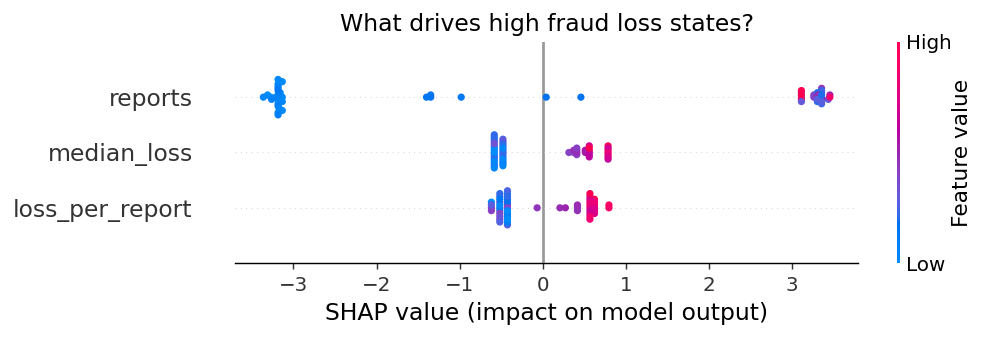

Saved chart6_shap.png

Predictions saved to output/predictions.csv

Risk tier breakdown:
risk_tier
Low Risk       26
High Risk      25
Medium Risk     1
Name: count, dtype: int64

Top 5 highest risk states:
         state  total_loss  fraud_probability  risk_tier
2      Arizona   336716502           0.986566  High Risk
9      Florida   866069909           0.986566  High Risk
5     Colorado   210727907           0.986566  High Risk
4   California  1678703608           0.986566  High Risk
47    Virginia   293690299           0.986566  High Risk


In [24]:
# ── Train XGBoost model ──────────────────────────────────────────────
features = ['reports', 'median_loss', 'loss_per_report']
X = df_ml[features]
y = df_ml['high_loss']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Train model
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

# Evaluate
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

print("=== MODEL RESULTS ===")
print(classification_report(y_test, preds, target_names=['Low Loss', 'High Loss']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, probs):.3f}")

# ── SHAP explainability ──────────────────────────────────────────────
explainer = shap.Explainer(model)
shap_values = explainer(X)

plt.figure(figsize=(8, 4))
shap.summary_plot(shap_values, X, feature_names=features, show=False)
plt.title('What drives high fraud loss states?')
plt.tight_layout()
plt.savefig('../output/chart6_shap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved chart6_shap.png')

# ── Export predictions for Power BI ─────────────────────────────────
df_ml['predicted_high_loss'] = model.predict(X)
df_ml['fraud_probability']   = model.predict_proba(X)[:, 1]
df_ml['risk_tier'] = pd.cut(
    df_ml['fraud_probability'],
    bins=[0, 0.4, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

df_ml.to_csv('../output/predictions.csv', index=False)
print('\nPredictions saved to output/predictions.csv')
print('\nRisk tier breakdown:')
print(df_ml['risk_tier'].value_counts())
print('\nTop 5 highest risk states:')
print(df_ml[['state', 'total_loss', 'fraud_probability', 'risk_tier']]
      .sort_values('fraud_probability', ascending=False).head())